#📌 Extracción

### Reconocimiento de Datos

In [66]:
import pandas as pd

In [67]:
base = pd.read_json("/content/TelecomX_Data.json")

In [68]:
base.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [69]:
base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [70]:
base.dtypes

,0
customerID,object
Churn,object
customer,object
phone,object
internet,object
account,object


### Diccionario de datos

- `customerID`: número de identificación único de cada cliente
- `Churn`: si el cliente dejó o no la empresa
- `gender`: género (masculino y femenino)
- `SeniorCitizen`: información sobre si un cliente tiene o no una edad igual o mayor a 65 años
- `Partner`: si el cliente tiene o no una pareja
- `Dependents`: si el cliente tiene o no dependientes
- `tenure`: meses de contrato del cliente
- `PhoneService`: suscripción al servicio telefónico
- `MultipleLines`: suscripción a más de una línea telefónica
- `InternetService`: suscripción a un proveedor de internet
- `OnlineSecurity`: suscripción adicional de seguridad en línea
- `OnlineBackup`: suscripción adicional de respaldo en línea
- `DeviceProtection`: suscripción adicional de protección del dispositivo
- `TechSupport`: suscripción adicional de soporte técnico, menor tiempo de espera
- `StreamingTV`: suscripción de televisión por cable
- `StreamingMovies`: suscripción de streaming de películas
- `Contract`: tipo de contrato
- `PaperlessBilling`: si el cliente prefiere recibir la factura en línea
- `PaymentMethod`: forma de pago
- `Charges.Monthly`: total de todos los servicios del cliente por mes
- `Charges.Total`: total gastado por el cliente

#🔧 Transformación

# Limpieza de datos

## 1.- Se expanden aquellas columnas que contienen diccionarios como valores

## 2.- Se identifican columnas con formato str donde los valores son "Yes" y "No" los cuales se reemplazan por 1 y 0 respectivamente

## 3.- La comuna "Charges.Total" está originalmente como tipo object y se cambia a tipo float

In [72]:
cust_expand = pd.json_normalize(base["customer"])
base = pd.concat([base.drop("customer", axis=1), cust_expand], axis=1)
phone_expand = pd.json_normalize(base["phone"])
base = pd.concat([base.drop("phone", axis=1), phone_expand], axis=1)
internet_expand = pd.json_normalize(base["internet"])
base = pd.concat([base.drop("internet", axis=1), internet_expand], axis=1)
account_expand = pd.json_normalize(base["account"])
base = pd.concat([base.drop("account", axis=1), account_expand], axis=1)
base["Partner"] = base["Partner"].replace({"Yes": 1, "No": 0}).astype(int)
base["Dependents"] = base["Dependents"].replace({"Yes": 1, "No": 0}).astype(int)
base["PhoneService"] = base["PhoneService"].replace({"Yes": 1, "No": 0})
base['Charges.Total'] = base['Charges.Total'].replace({" ": 0})
base["Charges.Total"] = base["Charges.Total"].astype(float)
base['Cuentas_diarias'] = base['Charges.Monthly'] / 30
base.head()

/tmp/ipykernel_330/373960.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  base["Partner"] = base["Partner"].replace({"Yes": 1, "No": 0}).astype(int)
/tmp/ipykernel_330/373960.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  base["Dependents"] = base["Dependents"].replace({"Yes": 1, "No": 0}).astype(int)
/tmp/ipykernel_330/373960.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_diarias
0,0002-ORFBO,No,Female,0,1,1,9,1,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,No,Male,0,0,0,9,1,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,Yes,Male,0,0,0,4,1,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,1,0,13,1,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,1,0,3,1,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667


In [73]:
base.describe()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,Charges.Monthly,Charges.Total,Cuentas_diarias
count,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000
mean,0.162653,0.484106,0.300124,32.346498,0.902711,64.720098,2277.182035,2.157337
std,0.369074,0.499782,0.458343,24.571773,0.296371,30.129572,2268.648587,1.004319
min,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,0.000000,0.608333
25%,0.000000,0.000000,0.000000,9.000000,1.000000,35.425000,396.200000,1.180833
50%,0.000000,0.000000,0.000000,29.000000,1.000000,70.300000,1389.200000,2.343333
75%,0.000000,1.000000,1.000000,55.000000,1.000000,89.875000,3778.525000,2.995833
max,1.000000,1.000000,1.000000,72.000000,1.000000,118.750000,8684.800000,3.958333


In [74]:
base.dtypes

,0
customerID,object
Churn,object
gender,object
SeniorCitizen,int64
Partner,int64
Dependents,int64
tenure,int64
PhoneService,int64
MultipleLines,object
InternetService,object


# Depuración de valores

### Para tener una base limpia y lista para utilizarse, se idenfitica que en la columna "Churn" existen valores vacíos, se excluyen estos para concentrarnos únicamente en aquellos valores que aporten valor al análisis.

### En total se eliminan 224 registros que representan el 4% de la base total.

In [75]:
base = base[base['Churn'] != '']
base.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_diarias
0,0002-ORFBO,No,Female,0,1,1,9,1,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,No,Male,0,0,0,9,1,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,Yes,Male,0,0,0,4,1,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,1,0,13,1,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,1,0,3,1,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667


#📊 Carga y análisis

# Participación de permanencia de clientes totales

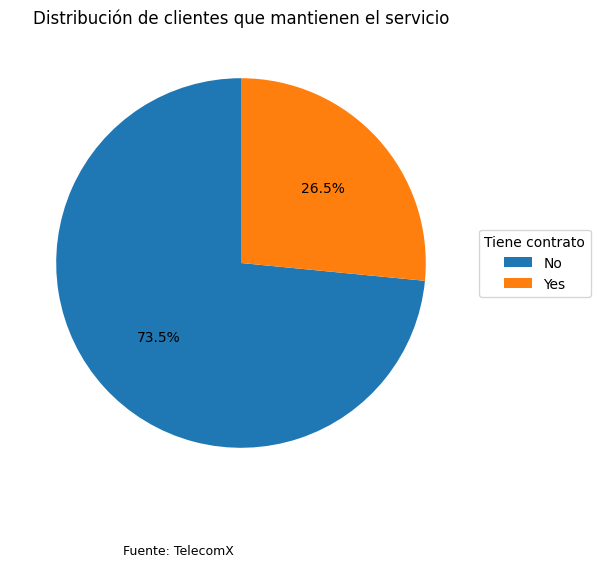

In [91]:
Participación = base.groupby(['Churn'])['Charges.Total'].count().reset_index(name="Variable")
Participación['Porcentaje'] = round(Participación['Variable'] / Participación['Variable'].sum() * 100, 2)

fig, ax = plt.subplots(figsize=(6,6))

wedges, texts, autotexts = ax.pie(Participación["Variable"], labels=None, autopct="%1.1f%%", startangle=90)

ax.legend( wedges, Participación["Churn"], title="Tiene contrato", loc="center left", bbox_to_anchor=(1, 0.5))

plt.figtext(0.5, 0.01, "Fuente: TelecomX", ha="right", fontsize=9)

plt.title("Distribución de clientes que mantienen el servicio")

plt.show()

# Del grupo de clientes que deciden terminar con el servicio, se observa que el 90% **si** contaba con servicio de telefonía, si el costo del servicio fuese motivo para dejar de contratar el servicio, se podrían coordinar con ventas y marketing la propuesta de lanzar paquetes sin servicio telefónico ya que no es un aliciente hacia el cliente para mantener el servicio.

In [92]:
Servicio_Telefónico = base.groupby(['Churn', 'PhoneService'])['Charges.Total'].count().reset_index(name="Variable")
Servicio_Telefónico = Servicio_Telefónico[Servicio_Telefónico['Churn'] != "Yes"]
Servicio_Telefónico['Porcentaje'] = round(Servicio_Telefónico['Variable'] / Servicio_Telefónico['Variable'].sum() * 100, 2)
Servicio_Telefónico

,Churn,PhoneService,Variable,Porcentaje
0,No,0,512,9.9
1,No,1,4662,90.1


# Del grupo de clientes que decidieron no continuar con el servicio, se observa que el mayor impacto en pérdida viene de aquellos que tenían un contrato a 2 años

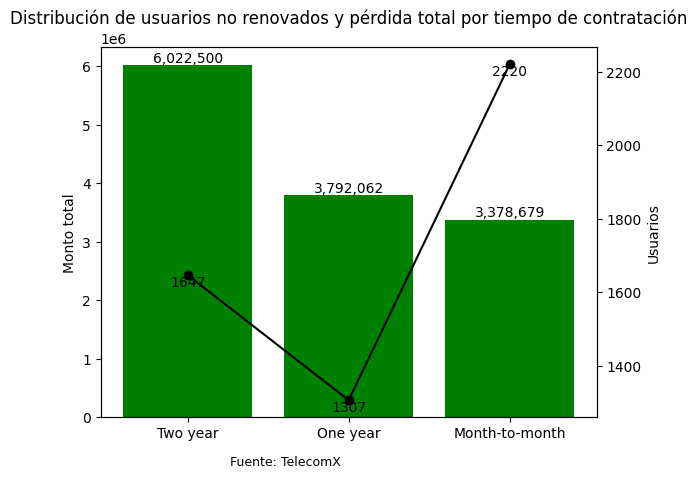

In [114]:
número_de_clientes_por_tipo_de_contrato = base.groupby(['Churn', 'Contract'])['Churn'].count().reset_index(name="Conteo de clientes")
número_de_clientes_por_tipo_de_contrato = número_de_clientes_por_tipo_de_contrato[número_de_clientes_por_tipo_de_contrato['Churn'] != "Yes"]
número_de_clientes_por_tipo_de_contrato['Porcentaje'] = round(número_de_clientes_por_tipo_de_contrato['Conteo de clientes'] / número_de_clientes_por_tipo_de_contrato['Conteo de clientes'].sum() * 100, 2)

monto_por_tipo_de_contrato = base.groupby(['Churn', 'Contract'])['Charges.Total'].sum().reset_index(name="Monto total")
monto_por_tipo_de_contrato = monto_por_tipo_de_contrato[monto_por_tipo_de_contrato['Churn'] != "Yes"]


Tipo_de_contrato = pd.concat([número_de_clientes_por_tipo_de_contrato, monto_por_tipo_de_contrato['Monto total']], axis=1)
#Tipo_de_contrato['Pérdida estimada'] = Tipo_de_contrato['Conteo de clientes']*Tipo_de_contrato['Monto promedio']
Tipo_de_contrato = Tipo_de_contrato.sort_values(by='Monto total', ascending=False)
Tipo_de_contrato

import matplotlib.pyplot as plt

fig, ax1 = plt.subplots()

# barras (pérdida estimada)
barras = ax1.bar(Tipo_de_contrato["Contract"], Tipo_de_contrato["Monto total"], color='green')
ax1.set_ylabel("Monto total")

# etiquetas en barras
for barra in barras:
    altura = barra.get_height()
    ax1.text( barra.get_x() + barra.get_width()/2, altura, f'{altura:,.0f}', ha='center', va='bottom')

# segundo eje
ax2 = ax1.twinx()

# línea (usuarios)
ax2.plot(Tipo_de_contrato["Contract"], Tipo_de_contrato["Conteo de clientes"], marker="o", color='black')
ax2.set_ylabel("Usuarios")

for x, y in zip(Tipo_de_contrato["Contract"], Tipo_de_contrato["Conteo de clientes"]):
    ax2.text(x, y, f'{y}', ha='center', va='top', color='black')

plt.title("Distribución de usuarios no renovados y pérdida total por tiempo de contratación")
plt.figtext(0.5, 0.01, "Fuente: TelecomX", ha="right", fontsize=9)
plt.show()

# Del grupo de clientes que decidieron no seguir con el servicio se observa que el 40% tenía contratado Internet con fibra óptica + Servicio de Streaming, sería bueno explorar la experiencia que tuvieron con la velocidad de carga o si se puede generar un paquete de streaming más atractivo para el usuario.

In [108]:
Internet = base.groupby(['Churn', 'InternetService', 'StreamingTV'])['Charges.Total'].sum().reset_index(name="Costo total")
Internet = Internet[Internet['Churn'] != "Yes"]
Internet['Porcentaje'] = round(Internet['Costo total'] / Internet['Costo total'].sum() * 100, 2)
Internet

,Churn,InternetService,StreamingTV,Costo total,Porcentaje
0,No,DSL,No,1944463.55,14.74
1,No,DSL,Yes,2816930.80,21.35
2,No,Fiber optic,No,2085709.10,15.81
3,No,Fiber optic,Yes,5354656.40,40.59
4,No,No,No internet service,991481.95,7.52


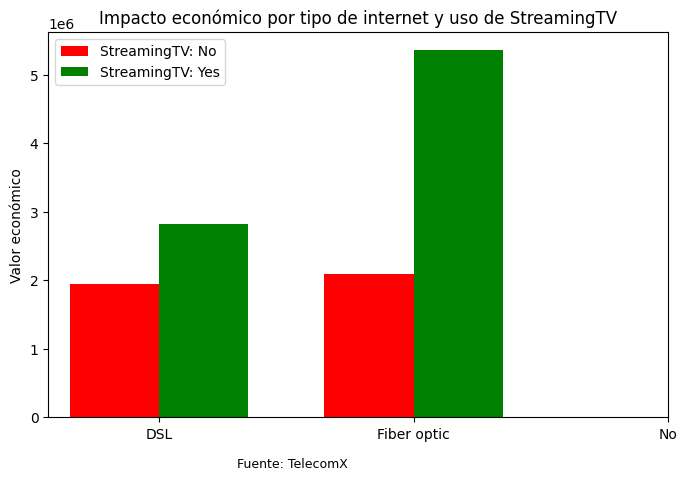

In [115]:
import matplotlib.pyplot as plt
import numpy as np

pivot = Internet.pivot(index="InternetService", columns="StreamingTV", values="Costo total")

x = np.arange(len(pivot.index))
width = 0.35

fig, ax = plt.subplots(figsize=(8,5))

bars1 = ax.bar(x - width/2, pivot["No"], width, label="StreamingTV: No", color="red")
bars2 = ax.bar(x + width/2, pivot["Yes"], width, label="StreamingTV: Yes", color="green")

ax.set_xticks(x)
ax.set_xticklabels(pivot.index)
ax.set_ylabel("Valor económico")
ax.set_title("Impacto económico por tipo de internet y uso de StreamingTV")

ax.legend()
plt.figtext(0.5, 0.01, "Fuente: TelecomX", ha="right", fontsize=9)
plt.show()

#📄Informe final

# Hallazgos

- De un total de 7,267 registros, se eliminaron aquellos que no tenían información en el campo "Churn", quedando únicamente 7,043 registros equivalente al 97% de los datos originales.

-  Al evaluar la variable "Churn" se observa que el 73.4% de los usuarios decidieron **NO** continuar con el servicio.

- Del subconjunto de clientes que no continuaron con el servicio, se encontró que el 90% de clientes contaba con un servicio de telefonía, sin embargo, este servicio en particular no era suficiente para mantener al cliente.

  *Como acción se propone revisar con el equipo de ventas si se pueden generar paquetes que no incluyan telefónía ya que no es un servicio que el cliente utilice y únicamente le está aumentando el costo a los paquetes actuales.*


- Se observa que de los clientes que decidieron no continuar con el servicio, los que tenían un contrato por dos años generaban la mayor pérdida, se podrían explorar o reforzar condiciones más a corto plazo.

  *Como acción se propone revisar la duración actual de los contratos para tener condiciones más atractivas y actualizadas a los clientes*


- Se observa que de los clientes que decidieron no continuar con el servicio, aquellos que tenían contratado un servicio de streaming + servicio de fibra óptica representan el 40%.

  *Como acción se propone lanzar una encuesta de satisfacción sobre el servicio recibido a aquellos usuarios que tienen contratada la fibra óptica para entender si la decisión pudiera ser por el servicio como tal o por el precio actual*